<a href="https://colab.research.google.com/github/avxsharma-glitch/Seasonal_Agriculture-Analysis---VOIS/blob/main/Seasonal_Agriculture_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis
## Full Data Cleaning, Preprocessing & Exploratory Analysis

This notebook contains the complete workflow for the VOIS AICTE Major Project:
**Seasonal Agriculture Performance Analysis**

Workflow:
1. Import libraries
2. Load dataset
3. Inspect structure and data types
4. Check missing values and duplicates
5. Clean numeric and categorical data
6. Handle missing values
7. Check outliers
8. Create derived features
9. Encode categorical variables
10. Prepare an analysis-ready dataset
11. Perform seasonal, crop, irrigation and regional analysis
12. Create visualizations
13. Run statistical tests
14. Export cleaned data and summary tables

**Important:** The original dataset is preserved in `df_raw`; cleaning is performed on a copy called `df`.


In [8]:
# 1. Import libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, pearsonr

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")


Libraries imported successfully.


In [9]:
# 2. Load the dataset
FILE_PATH = r"/content/seasonal_agriculture_performance_dataset (1).csv"

df_raw = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
display(df_raw.head())


Dataset loaded successfully.
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [10]:
# 3. Basic dataset inspection

print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("Data Type"))

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nLast 5 rows:")
display(df_raw.tail())


Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Last 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [11]:
# 4. Create a working copy

df = df_raw.copy()

# Standardize column names:
# - remove leading/trailing spaces
# - replace spaces and special separators with underscores
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
      .str.strip("_")
)

print("Cleaned column names:")
print(df.columns.tolist())


Cleaned column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [12]:
# 5. Identify column types

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print(numeric_columns)

print("\nCategorical columns:", len(categorical_columns))
print(categorical_columns)


Numeric columns: 22
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns: 6
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [13]:
# 6. Check duplicate records

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


Duplicate rows: 0
No duplicate rows found.


In [14]:
# 7. Missing-value analysis

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct
}).sort_values("Missing_Count", ascending=False)

display(missing_report[missing_report["Missing_Count"] > 0])


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [15]:
# 8. Check unique values in categorical columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique(dropna=True))
    print(df[col].value_counts(dropna=False).head(20))



--- Farm_ID ---
Unique values: 4000
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
SF13974    1
SF13973    1
SF13972    1
SF13971    1
SF13970    1
SF13969    1
SF10032    1
SF10031    1
SF10030    1
SF10029    1
Name: count, dtype: int64

--- State ---
Unique values: 8
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District ---
Unique values: 10
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop ---
Unique values: 8
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [16]:
# 9. Standardize text/categorical values

for col in categorical_columns:
    df[col] = df[col].astype("string").str.strip()

print("Categorical text standardized.")


Categorical text standardized.


In [17]:
# 10. Convert numeric-looking columns to numeric when appropriate

# This safely converts columns that are already numeric or contain numeric strings.
for col in df.columns:
    if df[col].dtype == "object":
        converted = pd.to_numeric(df[col], errors="coerce")
        original_non_null = df[col].notna().sum()
        converted_non_null = converted.notna().sum()

        # Convert only when most non-null values are numeric.
        if original_non_null > 0 and converted_non_null / original_non_null >= 0.95:
            df[col] = converted

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))


Numeric columns: 22
Categorical columns: 6


In [18]:
# 11. Handle missing values

# Recalculate column types after conversion.
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

# Numeric variables:
# Use median because it is less sensitive to extreme observations than the mean.
for col in numeric_columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical variables:
# Use the mode when available.
for col in categorical_columns:
    if df[col].isna().any():
        mode = df[col].mode(dropna=True)
        if len(mode) > 0:
            df[col] = df[col].fillna(mode.iloc[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("Missing-value treatment completed.")
print("Remaining missing values:", int(df.isna().sum().sum()))


Missing-value treatment completed.
Remaining missing values: 0


In [19]:
# 12. Validate numeric ranges and impossible values

# Negative values are not valid for most agricultural quantity measures.
# We inspect them first rather than deleting values automatically.

for col in numeric_columns:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"{col}: {negative_count} negative values")

print("\nNumeric summary:")
display(df[numeric_columns].describe().T)


Profit_INR: 1966 negative values

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [20]:
# 13. Outlier detection using the IQR rule

outlier_report = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_report.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(count),
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_report = pd.DataFrame(outlier_report).sort_values(
    "Outlier_Count", ascending=False
)

display(outlier_report)


,Column,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-148731.750,216187.75000,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,5.020,24.35500,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,1.661,5.15025,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,1.050,2.83000,-1.620000,5.500000e+00,302,7.55
19,Water_Used_m3,2268.750,7829.75000,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,207517.250,836874.75000,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,86.200,123.60000,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,6.600,8.10000,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,46.200,69.40000,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,143.975,227.20000,19.137500,3.520375e+02,15,0.38


### Outlier treatment decision

Outliers are **not automatically deleted**. Agricultural datasets can legitimately contain large farms, high yields, unusual weather conditions, or high profits. The IQR report is used to investigate unusual observations rather than removing them blindly.


In [21]:
# 14. Check important project columns

expected_columns = [
    "Season",
    "State",
    "Crop",
    "Irrigation_Method",
    "Yield_Tonnes_Ha",
    "Farm_Area_Hectares",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

available = [c for c in expected_columns if c in df.columns]
missing_expected = [c for c in expected_columns if c not in df.columns]

print("Available project columns:")
print(available)

if missing_expected:
    print("\nColumns not found:")
    print(missing_expected)


Available project columns:
['Season', 'State', 'Crop', 'Irrigation_Method', 'Yield_Tonnes_Ha', 'Farm_Area_Hectares', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [22]:
# 15. Feature engineering

# Profit per hectare
if {"Profit_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Profit_per_Ha_INR"] = np.where(
        df["Farm_Area_Hectares"] > 0,
        df["Profit_INR"] / df["Farm_Area_Hectares"],
        np.nan
    )

# Revenue per hectare
if {"Revenue_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Revenue_per_Ha_INR"] = np.where(
        df["Farm_Area_Hectares"] > 0,
        df["Revenue_INR"] / df["Farm_Area_Hectares"],
        np.nan
    )

# Refill any derived missing values with the median.
for col in ["Profit_per_Ha_INR", "Revenue_per_Ha_INR"]:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())

print("Feature engineering completed.")
display(df.head())


Feature engineering completed.


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_per_Ha_INR,Revenue_per_Ha_INR
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-22362.264151,58132.075472
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-69211.332312,6186.983155
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-25667.489712,39190.534979
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-21267.555556,44608.888889
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-34287.885986,45987.410926


In [23]:
# 16. Final cleaned-data quality check

print("Final shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", int(df.isna().sum().sum()))

print("\nData types after cleaning:")
display(df.dtypes.to_frame("Data Type"))

print("\nFinal descriptive statistics:")
display(df.describe(include="all").T)


Final shape: (4000, 30)
Duplicate rows: 0
Total missing values: 0

Data types after cleaning:


,Data Type
Farm_ID,string[python]
State,string[python]
District,string[python]
Crop,string[python]
Season,string[python]
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Final descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13985,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,4000.0,NaN,NaN,NaN,600.922825,287.193381,80.0,371.575,582.0,831.975,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [24]:
# 17. Save the cleaned dataset

CLEANED_FILE = "seasonal_agriculture_cleaned.csv"

df.to_csv(CLEANED_FILE, index=False)

print("Cleaned dataset saved as:", CLEANED_FILE)


Cleaned dataset saved as: seasonal_agriculture_cleaned.csv


# Exploratory Data Analysis
The following sections answer the project's main analytical questions using the cleaned dataset.


In [25]:
# 18. Seasonal performance summary

season_summary = df.groupby("Season").agg(
    Records=("Season", "size"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Profit_per_Ha_INR=("Profit_per_Ha_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_summary)


,Records,Avg_Yield_Tonnes_Ha,Avg_Profit_INR,Avg_Profit_per_Ha_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,1779,5.63,178914.65,21881.81,6102.20,5.89,54.47
Rabi,1627,5.04,87689.47,10361.68,5846.99,5.19,40.48
Zaid,594,4.64,-24804.82,-2636.52,6419.89,4.41,38.22


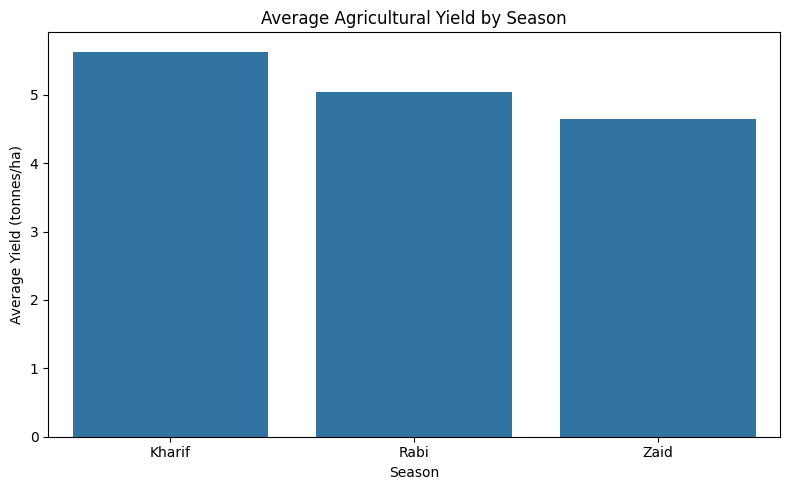

In [26]:
# 19. Average yield by season

plt.figure(figsize=(8, 5))
sns.barplot(data=season_summary.reset_index(), x="Season", y="Avg_Yield_Tonnes_Ha")
plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


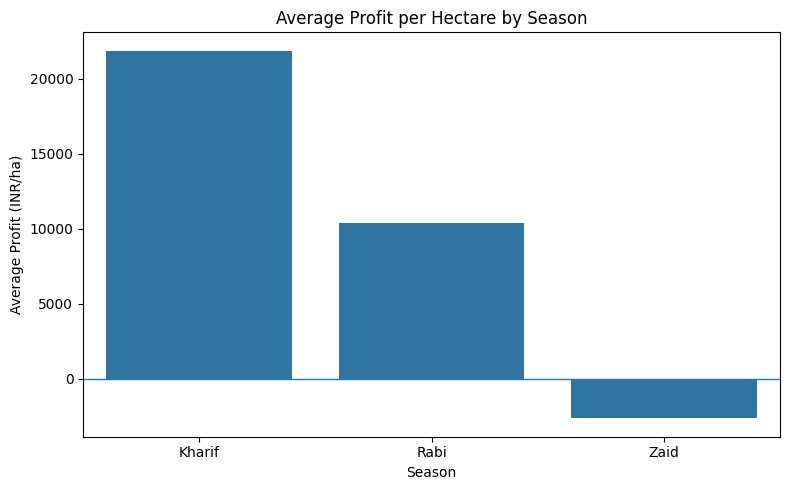

In [27]:
# 20. Average profit per hectare by season

plt.figure(figsize=(8, 5))
sns.barplot(data=season_summary.reset_index(), x="Season", y="Avg_Profit_per_Ha_INR")
plt.title("Average Profit per Hectare by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR/ha)")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()


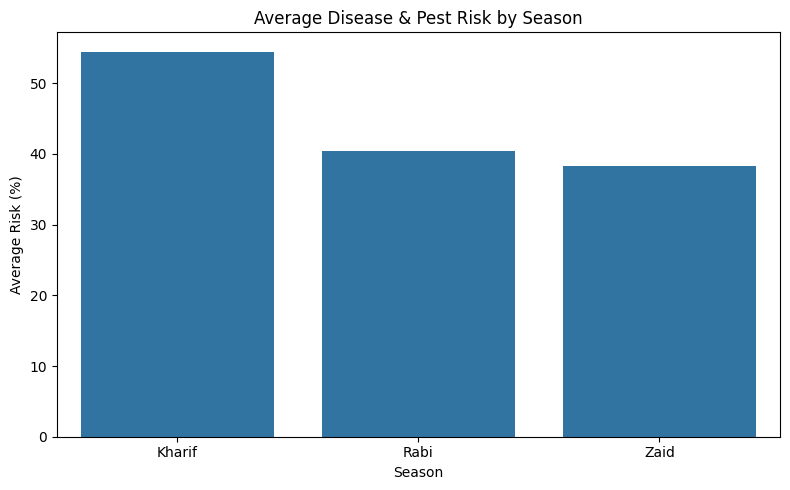

In [28]:
# 21. Disease and pest risk by season

plt.figure(figsize=(8, 5))
sns.barplot(
    data=season_summary.reset_index(),
    x="Season",
    y="Avg_Disease_Pest_Risk_pct"
)
plt.title("Average Disease & Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Average Risk (%)")
plt.tight_layout()
plt.show()


In [29]:
# 22. Irrigation-method analysis

irrigation_summary = df.groupby("Irrigation_Method").agg(
    Records=("Irrigation_Method", "size"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Yield_Tonnes_Ha", ascending=False).round(2)

display(irrigation_summary)


,Records,Avg_Yield_Tonnes_Ha,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,219626.00,5918.75,6.27
Sprinkler,734,5.16,91121.08,6208.26,4.67
Flood,1310,4.86,73354.02,8026.47,3.44
Rainfed,1041,4.60,79050.37,3549.55,7.56


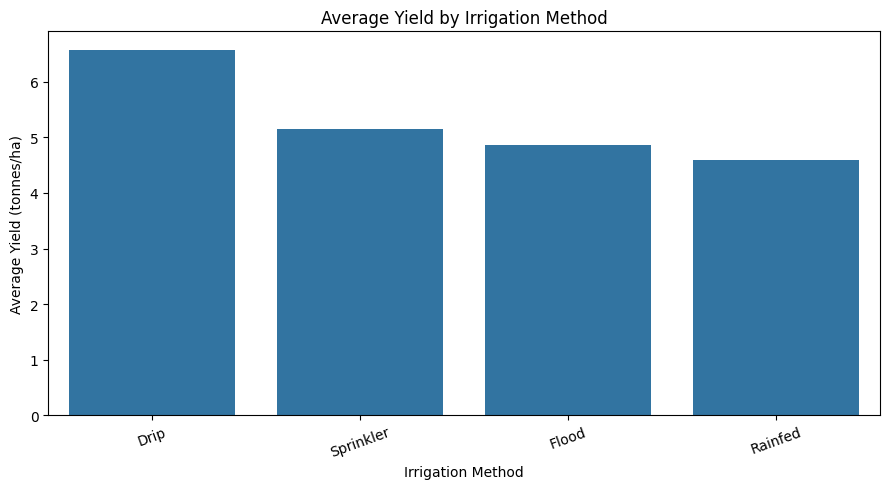

In [30]:
# 23. Irrigation vs average yield

plt.figure(figsize=(9, 5))
sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Avg_Yield_Tonnes_Ha"
)
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [31]:
# 24. Crop-level profitability

crop_summary = df.groupby("Crop").agg(
    Records=("Crop", "size"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Profit_per_Ha_INR=("Profit_per_Ha_INR", "mean")
).sort_values("Avg_Profit_per_Ha_INR", ascending=False).round(2)

display(crop_summary)


,Records,Avg_Yield_Tonnes_Ha,Avg_Profit_INR,Avg_Profit_per_Ha_INR
Crop,,,,
Sugarcane,305,46.64,817187.99,97169.92
Chilli,412,1.54,750878.34,92123.09
Cotton,508,1.23,124546.92,16354.22
Groundnut,424,1.32,44858.12,7443.69
Pulses,496,0.92,-4238.05,-693.36
Maize,551,2.71,-83978.33,-10203.08
Rice,690,2.43,-102213.50,-13137.46
Wheat,614,2.11,-123398.34,-15968.82


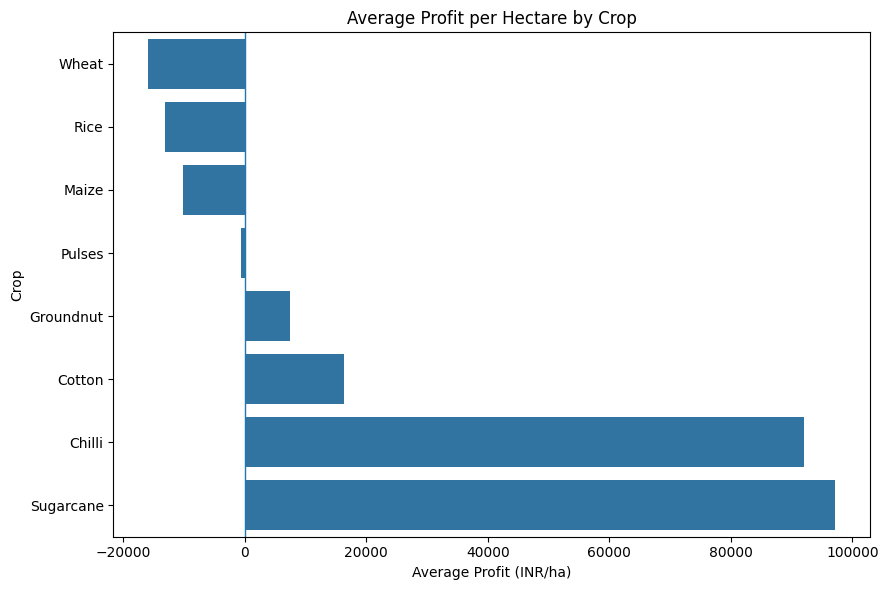

In [32]:
# 25. Average profit per hectare by crop

plot_data = crop_summary.sort_values("Avg_Profit_per_Ha_INR")

plt.figure(figsize=(9, 6))
sns.barplot(
    data=plot_data.reset_index(),
    y="Crop",
    x="Avg_Profit_per_Ha_INR"
)
plt.title("Average Profit per Hectare by Crop")
plt.xlabel("Average Profit (INR/ha)")
plt.ylabel("Crop")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()


In [33]:
# 26. State-level yield analysis

state_summary = (
    df.groupby("State")["Yield_Tonnes_Ha"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

display(state_summary.to_frame("Average_Yield_Tonnes_Ha"))


,Average_Yield_Tonnes_Ha
State,
Punjab,6.12
Karnataka,5.69
Gujarat,5.66
Telangana,5.04
Maharashtra,5.02
Madhya Pradesh,4.99
Tamil Nadu,4.88
Andhra Pradesh,4.63


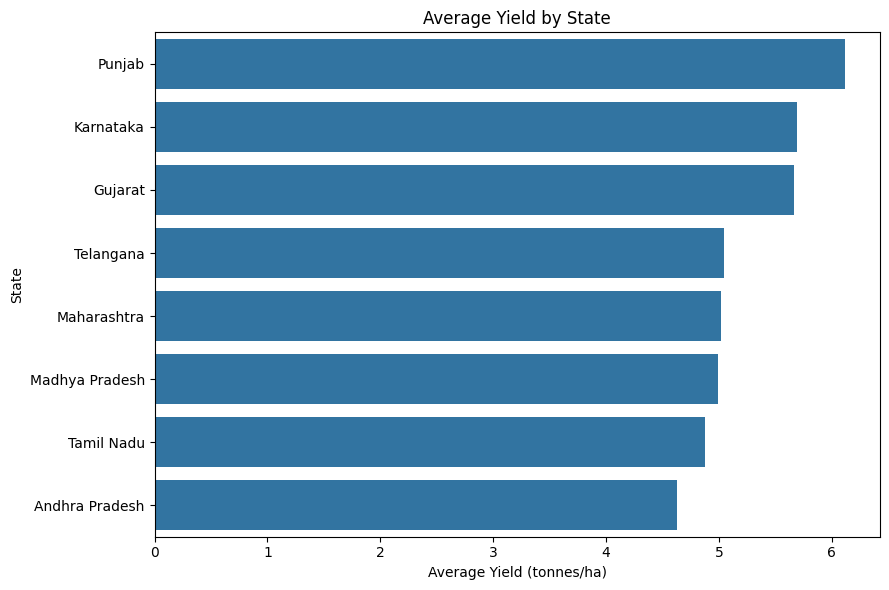

In [34]:
# 27. State vs average yield

plt.figure(figsize=(9, 6))
sns.barplot(
    x=state_summary.values,
    y=state_summary.index
)
plt.title("Average Yield by State")
plt.xlabel("Average Yield (tonnes/ha)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


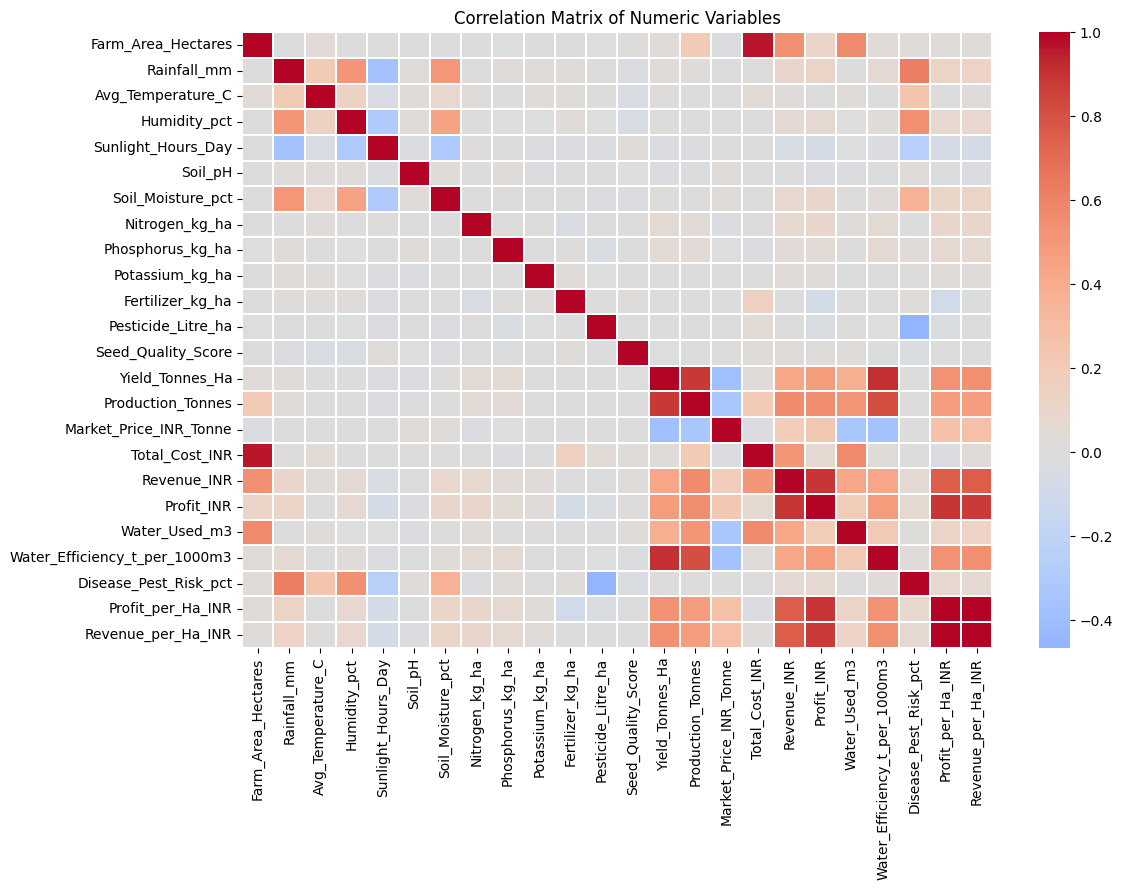

In [35]:
# 28. Correlation analysis

numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()


In [36]:
# 29. Variables most correlated with yield

yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

display(yield_correlations.to_frame("Correlation_with_Yield"))


,Correlation_with_Yield
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Revenue_per_Ha_INR,0.542074
Profit_per_Ha_INR,0.535367
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941


In [37]:
# 30. Statistical test: seasonal yield differences

yield_groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in df.groupby("Season")
]

yield_anova = f_oneway(*yield_groups)

print("Yield ANOVA")
print("F-statistic:", round(yield_anova.statistic, 4))
print("p-value:", round(yield_anova.pvalue, 6))

if yield_anova.pvalue < 0.05:
    print("Interpretation: Seasonal yield differences are statistically significant at the 5% level.")
else:
    print("Interpretation: The data does not provide statistically significant evidence of a seasonal yield difference at the 5% level.")


Yield ANOVA
F-statistic: 1.5439
p-value: 0.213678
Interpretation: The data does not provide statistically significant evidence of a seasonal yield difference at the 5% level.


In [38]:
# 31. Statistical test: seasonal profit differences

profit_groups = [
    group["Profit_INR"].dropna().values
    for _, group in df.groupby("Season")
]

profit_anova = f_oneway(*profit_groups)

print("Profit ANOVA")
print("F-statistic:", round(profit_anova.statistic, 4))
print("p-value:", profit_anova.pvalue)

if profit_anova.pvalue < 0.05:
    print("Interpretation: Seasonal profit differences are statistically significant at the 5% level.")
else:
    print("Interpretation: The data does not provide statistically significant evidence of seasonal profit differences at the 5% level.")


Profit ANOVA
F-statistic: 34.2918
p-value: 1.7124156677360182e-15
Interpretation: Seasonal profit differences are statistically significant at the 5% level.


In [39]:
# 32. Statistical test: seasonal disease/pest risk differences

risk_groups = [
    group["Disease_Pest_Risk_pct"].dropna().values
    for _, group in df.groupby("Season")
]

risk_anova = f_oneway(*risk_groups)

print("Disease/Pest Risk ANOVA")
print("F-statistic:", round(risk_anova.statistic, 4))
print("p-value:", risk_anova.pvalue)

if risk_anova.pvalue < 0.05:
    print("Interpretation: Seasonal disease/pest risk differences are statistically significant at the 5% level.")
else:
    print("Interpretation: The data does not provide statistically significant evidence of seasonal risk differences at the 5% level.")


Disease/Pest Risk ANOVA
F-statistic: 1049.4674
p-value: 0.0
Interpretation: Seasonal disease/pest risk differences are statistically significant at the 5% level.


In [40]:
# 33. Automatically generate a project findings table

best_yield_season = season_summary["Avg_Yield_Tonnes_Ha"].idxmax()
best_profit_season = season_summary["Avg_Profit_per_Ha_INR"].idxmax()
highest_risk_season = season_summary["Avg_Disease_Pest_Risk_pct"].idxmax()
best_irrigation = irrigation_summary["Avg_Yield_Tonnes_Ha"].idxmax()
best_crop = crop_summary["Avg_Profit_per_Ha_INR"].idxmax()

findings = pd.DataFrame({
    "Finding": [
        "Highest average yield season",
        "Highest average profit per hectare season",
        "Highest average disease/pest risk season",
        "Highest average yield irrigation method",
        "Highest average profit per hectare crop",
        "Yield ANOVA p-value",
        "Profit ANOVA p-value",
        "Risk ANOVA p-value"
    ],
    "Result": [
        f"{best_yield_season} ({season_summary.loc[best_yield_season, 'Avg_Yield_Tonnes_Ha']:.2f} t/ha)",
        f"{best_profit_season} (INR {season_summary.loc[best_profit_season, 'Avg_Profit_per_Ha_INR']:,.2f}/ha)",
        f"{highest_risk_season} ({season_summary.loc[highest_risk_season, 'Avg_Disease_Pest_Risk_pct']:.2f}%)",
        f"{best_irrigation} ({irrigation_summary.loc[best_irrigation, 'Avg_Yield_Tonnes_Ha']:.2f} t/ha)",
        f"{best_crop} (INR {crop_summary.loc[best_crop, 'Avg_Profit_per_Ha_INR']:,.2f}/ha)",
        f"{yield_anova.pvalue:.6f}",
        f"{profit_anova.pvalue:.6g}",
        f"{risk_anova.pvalue:.6g}"
    ]
})

display(findings)
findings.to_csv("seasonal_agriculture_key_findings.csv", index=False)


,Finding,Result
0,Highest average yield season,Kharif (5.63 t/ha)
1,Highest average profit per hectare season,"Kharif (INR 21,881.81/ha)"
2,Highest average disease/pest risk season,Kharif (54.47%)
3,Highest average yield irrigation method,Drip (6.58 t/ha)
4,Highest average profit per hectare crop,"Sugarcane (INR 97,169.92/ha)"
5,Yield ANOVA p-value,0.213678
6,Profit ANOVA p-value,1.71242e-15
7,Risk ANOVA p-value,0


# Conclusion

The analysis compares agricultural performance across seasons and examines crop, irrigation and state-level differences.

### Recommendations
- Use season-specific planning rather than relying on a single performance metric.
- Evaluate irrigation methods together with water consumption and crop type.
- Investigate crops or seasons with weak profitability before making planting decisions.
- Use multi-year data in future work to distinguish seasonal effects from year-to-year variation.
- A predictive model or interactive dashboard can be developed as the next phase.

### Limitation
The dataset is observational. Differences and correlations should not automatically be interpreted as causal relationships.
